# DeepVariant Variant Calling — Descriptive Analysis of Test Dataset

This notebook presents a descriptive analysis of the Variant Call Format (VCF) output generated by Google's DeepVariant model.

DeepVariant is a deep learning-based variant caller that converts aligned sequencing reads into images and applies a convolutional neural network (CNN) to identify SNPs and small insertions/deletions (Indels).

The objective of this notebook is to analyze the generated VCF file, summarize the detected variants, and visualize important statistics using Python.

## Setup

The following Python libraries are imported for reading the compressed VCF file, processing genomic variant information, and generating visualizations.

- gzip – reads compressed VCF files
- pandas – stores variant information in a DataFrame
- matplotlib – creates graphs for descriptive analysis
import gzip
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
import gzip
import pandas as pd
import matplotlib.pyplot as plt

## Loading DeepVariant Output

The compressed VCF file (`output.vcf.gz`) generated by DeepVariant is loaded and parsed. Header lines beginning with `#` are ignored, while variant records are extracted for downstream analysis.

In [2]:
import gzip

vcf_file = r"C:\Users\Bhumi_Shaurya\deepvariant\quickstart-testdata\output.vcf.gz"

variants = []

with gzip.open(vcf_file, "rt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        parts = line.strip().split("\t")
        variants.append(parts)

print("Total variants:", len(variants))

Total variants: 288


## Creating the Variant DataFrame

The extracted variants are converted into a pandas DataFrame for easier manipulation, filtering and visualization.

The DataFrame stores chromosome, genomic position, reference allele, alternate allele, quality score and other metadata.

In [3]:
import pandas as pd

columns = ["CHROM","POS","ID","REF","ALT","QUAL","FILTER","INFO"]
df = pd.DataFrame(variants, columns=columns + ["FORMAT","SAMPLE"])

df.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,SAMPLE
0,chr20,9999996,.,A,ACT,39.5,PASS,.,GT:GQ:DP:AD:VAF:MID:PL,"1/1:38:44:0,44:1:small_model:39,42,0"
1,chr20,10000117,.,C,T,36.8,PASS,.,GT:GQ:DP:AD:VAF:MID:PL,"0/1:37:55:25,30:0.545455:small_model:36,0,48"
2,chr20,10000211,.,C,T,36.4,PASS,.,GT:GQ:DP:AD:VAF:MID:PL,"0/1:36:59:30,29:0.491525:small_model:36,0,51"
3,chr20,10000439,.,T,G,49.9,PASS,.,GT:GQ:DP:AD:VAF:MID:PL,"1/1:47:72:0,72:1:small_model:49,49,0"
4,chr20,10000598,.,T,A,51.5,PASS,.,GT:GQ:DP:AD:VAF:MID:PL,"1/1:47:46:0,46:1:small_model:51,49,0"


## Variant Type Distribution

Variants are classified into:

- SNP (Single Nucleotide Polymorphism)
- INDEL (Insertion/Deletion)

This visualization summarizes the proportion of each variant type detected by DeepVariant.

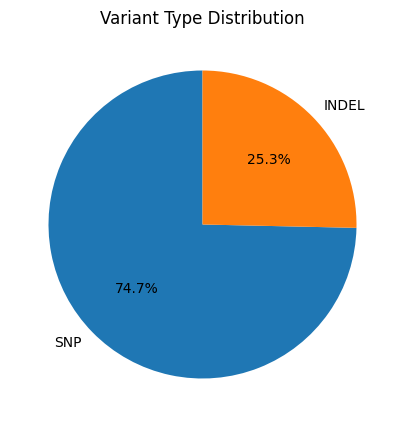

In [4]:
import matplotlib.pyplot as plt

variant_type = []

for i in range(len(df)):
    ref = df.loc[i, "REF"]
    alt = df.loc[i, "ALT"]

    if len(ref) == 1 and len(alt) == 1:
        variant_type.append("SNP")
    else:
        variant_type.append("INDEL")

counts = {
    "SNP": variant_type.count("SNP"),
    "INDEL": variant_type.count("INDEL")
}

plt.figure(figsize=(5,5))
plt.pie(counts.values(),
        labels=counts.keys(),
        autopct="%1.1f%%",
        startangle=90)
plt.title("Variant Type Distribution")
plt.show()

### Observation

Most detected variants are SNPs, while a smaller proportion consists of insertions and deletions (INDELs). This distribution is expected in typical human sequencing datasets.

## Variant Quality Distribution

DeepVariant assigns a quality (QUAL) score to every detected variant.

Higher QUAL scores indicate greater confidence that the detected variant is genuine rather than a sequencing artifact.

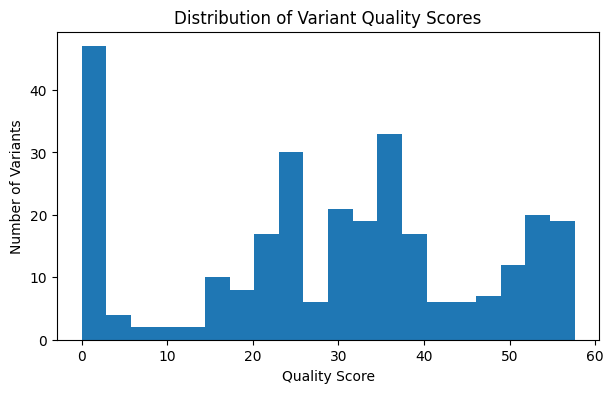

In [5]:
import matplotlib.pyplot as plt

df["QUAL"] = df["QUAL"].astype(float)

plt.figure(figsize=(7,4))
plt.hist(df["QUAL"], bins=20)
plt.xlabel("Quality Score")
plt.ylabel("Number of Variants")
plt.title("Distribution of Variant Quality Scores")
plt.show()

### Observation

The histogram shows the distribution of quality scores across all detected variants. Most variants have moderate to high confidence scores, indicating reliable variant calling.

## Variant Quality Across the Genome

This scatter plot visualizes the relationship between genomic position and variant quality score.

It helps identify whether confidence remains consistent throughout the analyzed chromosome.

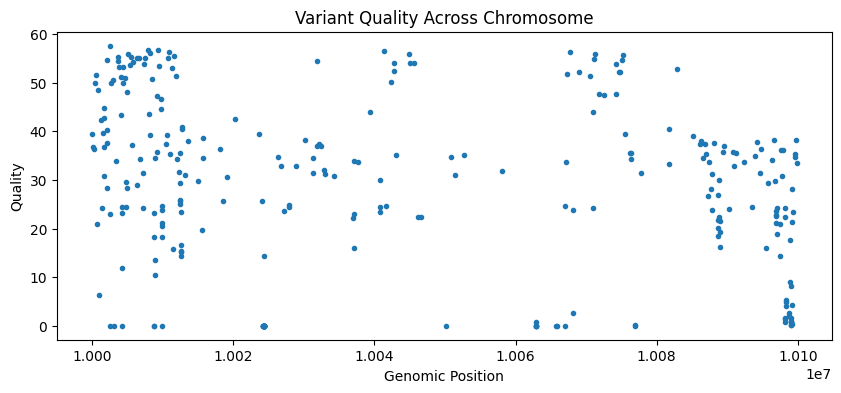

In [6]:
plt.figure(figsize=(10,4))
plt.plot(df["POS"].astype(int), df["QUAL"], "o", markersize=3)
plt.xlabel("Genomic Position")
plt.ylabel("Quality")
plt.title("Variant Quality Across Chromosome")
plt.show()

# Conclusion

DeepVariant successfully generated variant calls from the provided sequencing dataset.

The VCF output was parsed into a structured DataFrame and analyzed using Python.

The generated visualizations demonstrate:

- Variant type distribution
- Quality score distribution
- Quality variation across genomic positions

These analyses confirm the successful execution of the DeepVariant pipeline and provide a concise summary of the generated variant calls.